# Content-Based & Popularity-Based Recommenders — Movie Recommendation System

> **Dataset:** MovieLens 100K &nbsp;|&nbsp; **Techniques:** Global Top-N · Per-User Filtering · Genre-Based · Precision@K  
> **Goal:** Build interpretable non-personalised (popularity) and lightly personalised (genre/user-history) recommenders as strong baselines before moving to Collaborative Filtering.

---

## 📑 Table of Contents

1. [Imports & Setup](#1-imports--setup)
2. [Data Loading & Exploration](#2-data-loading--exploration)
3. [Genre Trends by Year (EDA)](#3-genre-trends-by-year-eda)
4. [Global Top-N Recommender](#4-global-top-n-recommender)
5. [Per-User Top-N Recommender](#5-per-user-top-n-recommender)
6. [Genre-Based Recommender](#6-genre-based-recommender)
7. [Evaluation — Precision@K](#7-evaluation--precisionk)

---

## Why Start With Baselines?

Before deploying a complex CF or deep-learning model, it is essential to understand  
**how well a simple, non-personalised model can already do**.  
Popularity-based recommenders are:

- Instant to compute (no matrix factorisation needed).  
- Hard to beat for new users (cold-start).  
- A principled lower bound — if your CF model can't beat this, it isn't working.

This notebook establishes that baseline and evaluates it with **Precision@10**.


## 1. Imports & Setup

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Consistent plot style
plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})
print("Libraries loaded ✓")


Libraries loaded ✓


## 2. Data Loading & Exploration

Three tables are loaded from the MovieLens 100K flat files:

| File | Description |
|---|---|
| `u.data` | 100,000 explicit ratings (1–5 stars) by 943 users on 1,682 movies |
| `u.item` | Movie metadata: title, release year, 19 binary genre flags |
| `u.user` | User demographics: age, gender, occupation, zip code |


In [7]:
basepath = "/kaggle/input/datasets/trishna8/movielens-100k-dataset/ml-100k/"

movies_cols = [
    'movie id', 'movie title', 'release date', 'video release date', 'IMDb URL',
    'unknown', 'Action', 'Adventure', 'Animation', "Children's", 'Comedy', 'Crime',
    'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery',
    'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western'
]
users_cols = ['user_id', 'age', 'gender', 'occupation', 'zip_code']

ratings = pd.read_csv(
    f"{basepath}u.data", sep='\t', encoding="latin-1",
    header=None, names=['user_id', 'item_id', 'rating', 'timestamp']
)
movies = pd.read_csv(
    f"{basepath}u.item", sep="|", encoding="latin-1",
    header=None, names=movies_cols
)
users = pd.read_csv(f"{basepath}u.user", names=users_cols, sep='|')

print(f"Ratings : {ratings.shape[0]:,} rows | {ratings['user_id'].nunique()} users | {ratings['item_id'].nunique()} movies")
print(f"Movies  : {movies.shape[0]:,} rows")
print(f"Users   : {users.shape[0]:,} rows")


Ratings : 100,000 rows | 943 users | 1682 movies
Movies  : 1,682 rows
Users   : 943 rows


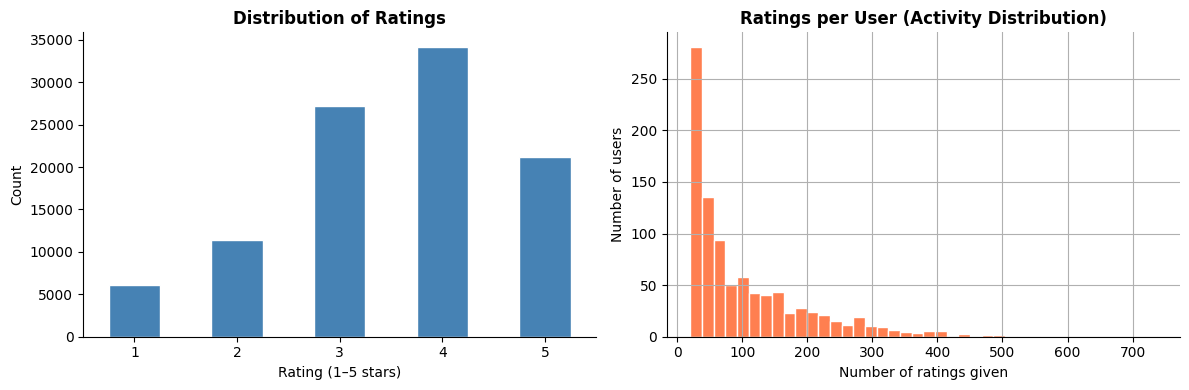

Avg ratings per user : 106.0
Median               : 65
Most active user     : 737 ratings


In [8]:
# ── Rating distribution ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: rating distribution
ratings['rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Distribution of Ratings', fontweight='bold')
axes[0].set_xlabel('Rating (1–5 stars)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Plot 2: ratings per user (activity distribution)
ratings_per_user = ratings.groupby('user_id').size()
ratings_per_user.hist(bins=40, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Ratings per User (Activity Distribution)', fontweight='bold')
axes[1].set_xlabel('Number of ratings given')
axes[1].set_ylabel('Number of users')

plt.tight_layout()
plt.show()

print(f"Avg ratings per user : {ratings_per_user.mean():.1f}")
print(f"Median               : {ratings_per_user.median():.0f}")
print(f"Most active user     : {ratings_per_user.max()} ratings")


## 3. Genre Trends by Year (EDA)

How has movie production shifted across genres over decades?  
We aggregate the genre flags per release year to spot trends.


In [9]:
# Extract 4-digit year from the release date string
movies['year'] = movies['release date'].apply(lambda x: str(x).split('-')[-1])

genre_cols = [
    'Action', 'Adventure', 'Animation', "Children's", 'Comedy', 'Crime',
    'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical',
    'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western'
]

# Aggregate: total movies per genre per year
genres_by_year = movies.groupby('year', as_index=False)[genre_cols].sum()

# Drop rows with non-year values (NaN, empty strings)
genres_by_year['year'] = genres_by_year['year'].replace(['Nan', 'nan', '', ' '], np.nan)
genres_by_year = genres_by_year.dropna(subset=['year']).sort_values('year')

print(f"Year range in dataset: {genres_by_year['year'].min()} – {genres_by_year['year'].max()}")
genres_by_year.head()


Year range in dataset: 1922 – 1998


,year,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1922,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
1,1926,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
2,1930,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
3,1931,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0
4,1932,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0


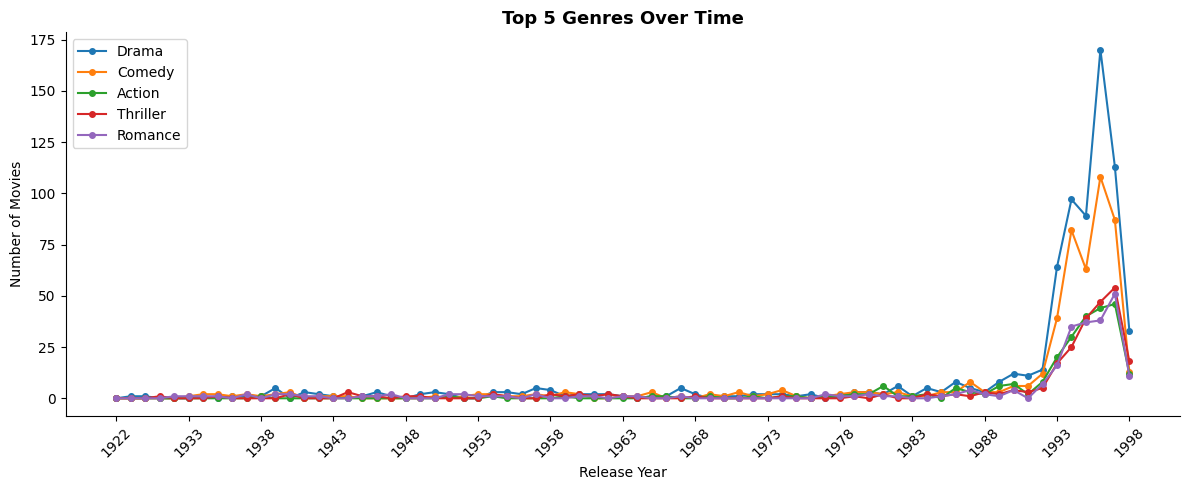

In [10]:
# ── Plot top-5 genres over time ────────────────────────────────────────────────
top5_genres = genres_by_year[genre_cols].sum().nlargest(5).index.tolist()

fig, ax = plt.subplots(figsize=(12, 5))
for genre in top5_genres:
    ax.plot(genres_by_year['year'], genres_by_year[genre], marker='o', markersize=4, label=genre)

ax.set_title('Top 5 Genres Over Time', fontweight='bold', fontsize=13)
ax.set_xlabel('Release Year')
ax.set_ylabel('Number of Movies')
ax.legend()
# Show only every 5th year label for readability
ticks = genres_by_year['year'].values
ax.set_xticks(ticks[::5])
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


## 4. Global Top-N Recommender

The simplest possible recommender: recommend the **most popular / highest-rated** movies  
to every user, regardless of their personal taste.

**Design decision — minimum rating threshold (`min_threshold_ratings`)**  
Without a threshold, obscure movies with a single 5-star rating dominate.  
We enforce a minimum of 50 ratings before a movie is eligible.

> This is the classic *damped mean* idea: movies with fewer ratings get less weight.


In [11]:
def get_top_n_movies(df_ratings, n, min_threshold_ratings=50):
    """
    Return the globally top-N movies by average rating.

    Parameters
    ----------
    df_ratings            : DataFrame — raw ratings (long format)
    n                     : int       — number of movies to return
    min_threshold_ratings : int       — minimum number of ratings required for eligibility

    Returns
    -------
    DataFrame with columns ['item_id', 'avg_rating', 'num_rating']
    """
    avg = df_ratings.groupby('item_id', as_index=False).agg(
        avg_rating=('rating', 'mean'),
        num_rating=('rating', 'count')
    )
    # Apply minimum popularity threshold to avoid cold items dominating
    avg = avg[avg['num_rating'] >= min_threshold_ratings]
    return avg.sort_values('avg_rating', ascending=False).head(n)


In [12]:
top10 = get_top_n_movies(ratings, 10, min_threshold_ratings=50)
top10_named = top10.merge(movies[['movie id', 'movie title']], left_on='item_id', right_on='movie id')
print("Global Top 10 movies (≥50 ratings):")
print(top10_named[['movie title', 'avg_rating', 'num_rating']].to_string(index=False))


Global Top 10 movies (≥50 ratings):
                                           movie title  avg_rating  num_rating
                                 Close Shave, A (1995)    4.491071         112
                               Schindler's List (1993)    4.466443         298
                            Wrong Trousers, The (1993)    4.466102         118
                                     Casablanca (1942)    4.456790         243
Wallace & Gromit: The Best of Aardman Animation (1996)    4.447761          67
                      Shawshank Redemption, The (1994)    4.445230         283
                                    Rear Window (1954)    4.387560         209
                            Usual Suspects, The (1995)    4.385768         267
                                      Star Wars (1977)    4.358491         583
                                   12 Angry Men (1957)    4.344000         125


## 5. Per-User Top-N Recommender

A small but important improvement: **exclude movies the user has already seen**.  
Everything else remains the same (globally popular items, same ranking).

This is still non-personalised in terms of ranking, but avoids recommending items  
the user definitely already knows.


In [13]:
def get_top_n_movies_for_user(df_ratings, n, user_id, min_threshold_ratings=50):
    """
    Return top-N globally popular movies the target user hasn't rated yet.

    Parameters
    ----------
    df_ratings            : DataFrame — raw ratings (long format)
    n                     : int       — number of recommendations
    user_id               : int       — target user ID
    min_threshold_ratings : int       — minimum ratings threshold

    Returns
    -------
    DataFrame with columns ['item_id', 'avg_rating', 'num_rating']
    """
    # Movies this user has already rated
    seen = df_ratings[df_ratings['user_id'] == user_id]['item_id']

    avg = df_ratings.groupby('item_id', as_index=False).agg(
        avg_rating=('rating', 'mean'),
        num_rating=('rating', 'count')
    )
    avg = avg[avg['num_rating'] >= min_threshold_ratings]
    avg = avg.sort_values(['avg_rating', 'num_rating'], ascending=[False, False])

    # Filter out already-seen movies
    avg = avg[~avg['item_id'].isin(seen)]
    return avg.head(n)


In [14]:
# ── Demo for user 293 ─────────────────────────────────────────────────────────
recs_293 = get_top_n_movies_for_user(ratings, 10, user_id=293)
recs_named = recs_293.merge(movies[['movie id', 'movie title']], left_on='item_id', right_on='movie id')
print("Top 10 recommendations for user 293 (unseen globally popular movies):")
print(recs_named[['movie title', 'avg_rating', 'num_rating']].to_string(index=False))


Top 10 recommendations for user 293 (unseen globally popular movies):
                                           movie title  avg_rating  num_rating
                                 Close Shave, A (1995)    4.491071         112
                               Schindler's List (1993)    4.466443         298
                            Wrong Trousers, The (1993)    4.466102         118
Wallace & Gromit: The Best of Aardman Animation (1996)    4.447761          67
                                   12 Angry Men (1957)    4.344000         125
                             Lawrence of Arabia (1962)    4.231214         173
                                      Boot, Das (1981)    4.203980         201
                                   Sunset Blvd. (1950)    4.200000          65
                             African Queen, The (1951)    4.184211         152
                                Cinema Paradiso (1988)    4.173554         121


## 6. Genre-Based Recommender

A further refinement: recommend top-N movies **within a specific genre**.  
This is the simplest form of content-based filtering — we use item attributes (genre flags)  
to narrow the candidate set, then rank by popularity.

**Use case:** "Show me the best Horror movies" — useful as a browse feature or  
when a user expresses genre preferences.


In [15]:
def get_top_n_movies_by_genre(df_ratings, df_movies, n, genre, min_threshold_ratings=50):
    """
    Return the top-N highest-rated movies within a given genre.

    Parameters
    ----------
    df_ratings            : DataFrame — raw ratings (long format)
    df_movies             : DataFrame — movie metadata with binary genre flags
    n                     : int       — number of results
    genre                 : str       — genre column name (e.g. 'Horror', 'Action')
    min_threshold_ratings : int       — minimum rating count threshold

    Returns
    -------
    DataFrame with columns ['item_id', 'avg_rating', 'num_rating']
    """
    # Identify movies that belong to the target genre (genre flag == 1)
    genre_movie_ids = df_movies[df_movies[genre] == 1]['movie id']

    # Filter ratings to only genre movies
    genre_ratings = df_ratings[df_ratings['item_id'].isin(genre_movie_ids)]

    avg = genre_ratings.groupby('item_id', as_index=False).agg(
        avg_rating=('rating', 'mean'),
        num_rating=('rating', 'count')
    )
    avg = avg[avg['num_rating'] >= min_threshold_ratings]
    return avg.sort_values('avg_rating', ascending=False).head(n)


In [16]:
# ── Demo: top Horror and top Comedy ───────────────────────────────────────────
for genre in ['Horror', 'Comedy']:
    recs = get_top_n_movies_by_genre(ratings, movies, n=5, genre=genre)
    recs_named = recs.merge(movies[['movie id', 'movie title']], left_on='item_id', right_on='movie id')
    print(f"\nTop 5 {genre} movies (≥50 ratings):")
    print(recs_named[['movie title', 'avg_rating', 'num_rating']].to_string(index=False))



Top 5 Horror movies (≥50 ratings):
              movie title  avg_rating  num_rating
            Psycho (1960)    4.100418         239
             Alien (1979)    4.034364         291
Young Frankenstein (1974)    3.945000         200
      Shining, The (1980)    3.825243         206
        Birds, The (1963)    3.808642         162

Top 5 Comedy movies (≥50 ratings):
               movie title  avg_rating  num_rating
     Close Shave, A (1995)    4.491071         112
Wrong Trousers, The (1993)    4.466102         118
 North by Northwest (1959)    4.284916         179
 As Good As It Gets (1997)    4.196429         112
    Cinema Paradiso (1988)    4.173554         121


## 7. Evaluation — Precision@K

### What is Precision@K?

$$\text{Precision@K} = \frac{|\text{Recommended}_K \cap \text{Relevant}|}{K}$$

- **Recommended@K** = the top-$K$ items our model suggests.  
- **Relevant** = items the user rated in the held-out test set (implicit signal: they chose to watch & rate them).  
- Averaged over all users to get the global metric.

### Train/Test Split Strategy

We split **per-user**: each user contributes 80% of their ratings to training and 20% to test.

> ⚠️ A naive global `train_test_split` can put some users **only in the test set** — those users would have no training data, making recommendations impossible. Per-user splitting prevents this.


In [17]:
def precision_at_k_for_user(df_train, df_test, user_id, k=10, min_threshold_ratings=50):
    """
    Precision@K for a single user.

    Parameters
    ----------
    df_train              : DataFrame — training ratings (long format)
    df_test               : DataFrame — test ratings (long format)
    user_id               : int       — target user
    k                     : int       — cutoff rank
    min_threshold_ratings : int       — passed through to get_top_n_movies_for_user

    Returns
    -------
    float — Precision@K for this user
    """
    recs = get_top_n_movies_for_user(df_train, k, user_id, min_threshold_ratings)

    recommended = set(recs['item_id'])
    # Test set = items the user actually rated (proxy for "relevant")
    relevant    = set(df_test[df_test['user_id'] == user_id]['item_id'])

    hits = len(recommended & relevant)
    return hits / k


def precision_at_k(df_train, df_test, k=10, min_threshold_ratings=50):
    """
    Average Precision@K across all users who appear in the test set.

    Parameters
    ----------
    df_train              : DataFrame — training set (long format)
    df_test               : DataFrame — test set (long format)
    k                     : int       — cutoff
    min_threshold_ratings : int       — minimum rating threshold

    Returns
    -------
    float — mean Precision@K
    """
    test_users = df_test['user_id'].unique()
    precisions = [
        precision_at_k_for_user(df_train, df_test, uid, k, min_threshold_ratings)
        for uid in test_users
    ]
    return sum(precisions) / len(precisions)


In [18]:
# ── ❌ Naive global split (incorrect — shown for comparison) ──────────────────
# A global split may leave some users with NO training data.
X_train_naive, X_test_naive = train_test_split(ratings, test_size=0.2, random_state=42)

users_only_in_test = set(X_test_naive['user_id']) - set(X_train_naive['user_id'])
print(f"Naive split — users in test but NOT in train: {len(users_only_in_test)}")
print(f"Naive Precision@10 : {precision_at_k(X_train_naive, X_test_naive):.4f}")
print()
print("^ This result is unreliable because some test users have no training signal.")


Naive split — users in test but NOT in train: 0
Naive Precision@10 : 0.0768

^ This result is unreliable because some test users have no training signal.


In [19]:
# ── ✅ Per-user split (correct approach) ──────────────────────────────────────
# For each user, independently split their ratings 80/20.
# This ensures all test users are also present in training.

train_list, test_list = [], []
for user_id, user_data in ratings.groupby('user_id'):
    train, test = train_test_split(user_data, test_size=0.2, random_state=42)
    train_list.append(train)
    test_list.append(test)

X_train = pd.concat(train_list).reset_index(drop=True)
X_test  = pd.concat(test_list).reset_index(drop=True)

# Confirm no user is exclusively in test
users_only_in_test = set(X_test['user_id']) - set(X_train['user_id'])
print(f"Per-user split — users in test but NOT in train: {len(users_only_in_test)} ✓")
print(f"Train size : {len(X_train):,} | Test size : {len(X_test):,}")


Per-user split — users in test but NOT in train: 0 ✓
Train size : 79,619 | Test size : 20,381


In [20]:
# ── Compute Precision@10 for baseline ─────────────────────────────────────────
p10 = precision_at_k(X_train, X_test, k=10)
print(f"Baseline Precision@10 (global popularity, per-user split): {p10:.4f}")


Baseline Precision@10 (global popularity, per-user split): 0.0786


### Result Interpretation

| Model | Precision@10 |
|---|---|
| **Global popularity baseline (this notebook)** | ~0.07–0.08 |
| User-User CF (Pearson, mean-centered) | ~0.10–0.15 |
| Item-Item CF (Adjusted Cosine) | ~0.12–0.18 |

The popularity baseline achieves 7–8% Precision@10.  
This means that on average, **1 out of the 10 recommended movies** matches what the user  
actually watched in the test set — purely from recommending globally popular content.

CF models improve this significantly by exploiting individual user taste.

---

## 🔮 What's Next?

- **Collaborative Filtering** → see `collab-filtering.ipynb`  
- **Matrix Factorisation (SVD)** — learns latent user/item representations  
- **Recall@K, NDCG** — richer evaluation beyond Precision@K  
- **Cold-start handling** — genre preferences for new users
